#A. Penerapan N-Gram

#1. Menghubungkan Google Colab Dengan Google Drive



In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#2. Import Library Yang Dibutuhkan

In [3]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer

#3. Load Dataset

In [4]:
file_path = "/content/drive/MyDrive/Colab Notebooks/TMFiturNGram/myIM3_Beli_Pulsa__Cek_Kuota.csv"

try:
    df = pd.read_csv(file_path)
    print("Dataset berhasil dimuat!")
    display(df.head())
except FileNotFoundError:
    print(f"File tidak ditemukan di path: {file_path}")
except Exception as e:
    print(f"Terjadi kesalahan: {e}")

Dataset berhasil dimuat!


,userName,content,score,at,appVersion
0,UCIL OLOL LEHO [UOL],Kenapa Indosat ada tuyulnya sekarang pulsa tib...,1,2024-02-02 05:17:07,82.0.5
1,Pp.joaana,aplikasi ini sangat bagus,5,2024-02-02 05:16:51,82.0.5
2,Xeraphine,Tolong itu sistem login nomor utama dan nomor ...,3,2024-02-02 05:13:29,NaN
3,Sugeng dian pamungkas,Sekarang pilihanya yg 30 hari naik terus harga...,4,2024-02-02 05:13:07,NaN
4,Bang Tinus,murah,5,2024-02-02 05:11:20,81.16.0


#4. Melihat Informasi Dataset Dan Cek Missing Value

In [5]:
print("Informasi Dataset:")
df.info()

print("\nJumlah Missing Value tiap kolom:")
display(df.isnull().sum())

if "score" in df.columns:
    print("\nStatistik Deskriptif Kolom Score:")
    display(df["score"].describe())

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   userName    10000 non-null  object
 1   content     10000 non-null  object
 2   score       10000 non-null  int64 
 3   at          10000 non-null  object
 4   appVersion  8026 non-null   object
dtypes: int64(1), object(4)
memory usage: 390.8+ KB

Jumlah Missing Value tiap kolom:


,0
userName,0
content,0
score,0
at,0
appVersion,1974



Statistik Deskriptif Kolom Score:


,score
count,10000.000000
mean,2.830100
std,1.827339
min,1.000000
25%,1.000000
50%,2.000000
75%,5.000000
max,5.000000


#5. Menampilkan Contoh Review

In [6]:
print("Contoh Review (5 data pertama):")
for i in range(5):
    print(f"Review {i+1}:\n{df['content'][i]}\n")

Contoh Review (5 data pertama):
Review 1:
Kenapa Indosat ada tuyulnya sekarang pulsa tiba-tiba berkurang padahal saya tidak punya paket dan data seluler selalu mati,,, Apakah Indosat memelihara tuyul

Review 2:
aplikasi ini sangat bagus

Review 3:
Tolong itu sistem login nomor utama dan nomor sekunder diaplikasi dihapuskan aja, cuma bikin ribet bikin repot ketika mau cek pulsa atau kuota antara nomor A dan nomor B. Selebihnya semua dah oke.

Review 4:
Sekarang pilihanya yg 30 hari naik terus harganya. Gak ada yg murah 🤦🤦

Review 5:
murah



#6. Stopwords + Cleaning Function

In [7]:
indonesian_stopwords = [
    "dan", "atau", "yang", "di", "ke", "dari", "pada", "untuk", "akan", "dengan",
    "itu", "ini", "ada", "tidak", "juga", "adalah", "sebagai", "oleh", "karena",
    "sehingga", "jika", "maka", "tetapi", "setelah", "sebelum", "walaupun",
    "bahwa", "apabila", "seharusnya", "cukup", "hanya", "ingin", "jangan",
    "lebih", "kurang", "lalu", "lain", "memang", "mungkin", "pasti", "sangat",
    "sama", "selalu", "selain", "selama", "semua", "sendiri", "seperti", "setiap",
    "sesuatu", "sesudah", "belum", "sudah", "bisa", "boleh", "harus", "perlu"
]

def clean_text(text):
    if pd.isna(text):
        return ""

    text = text.lower()
    text = re.sub(r'<.*?>', '', text)  # hapus html tag
    text = text.translate(str.maketrans('', '', string.punctuation))  # hapus punctuation
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)  # hapus simbol aneh

    # hapus stopwords
    text = ' '.join([word for word in text.split() if word not in indonesian_stopwords])

    # hapus spasi berlebih
    text = ' '.join(text.split())
    return text

#7. Menerapkan Cleaning ke Dataset

In [8]:
df["clean_content"] = df["content"].apply(clean_text)

print("Kolom clean_content berhasil dibuat!")
display(df[["content", "clean_content"]].head())

Kolom clean_content berhasil dibuat!


,content,clean_content
0,Kenapa Indosat ada tuyulnya sekarang pulsa tib...,kenapa indosat tuyulnya sekarang pulsa tibatib...
1,aplikasi ini sangat bagus,aplikasi bagus
2,Tolong itu sistem login nomor utama dan nomor ...,tolong sistem login nomor utama nomor sekunder...
3,Sekarang pilihanya yg 30 hari naik terus harga...,sekarang pilihanya yg 30 hari naik terus harga...
4,murah,murah


#8. CountVectorizer (Unigram + Bigram)

In [9]:
vectorizer = CountVectorizer(
    ngram_range=(1, 2),      # unigram dan bigram
    max_features=1000,
    max_df=0.95,
    min_df=2
)

X_ngrams = vectorizer.fit_transform(df["clean_content"])
print("Ekstraksi fitur N-Gram selesai!")

Ekstraksi fitur N-Gram selesai!


#9. Menampilkan Ukuran Kosakata/Vocabulary

In [10]:
vocabulary = vectorizer.vocabulary_

print("Ukuran kosakata n-gram:", len(vocabulary))
print("20 n-gram pertama:", list(vocabulary.items())[:20])

Ukuran kosakata n-gram: 1000
20 n-gram pertama: [('kenapa', np.int64(444)), ('indosat', np.int64(342)), ('sekarang', np.int64(819)), ('pulsa', np.int64(764)), ('tibatiba', np.int64(941)), ('berkurang', np.int64(128)), ('padahal', np.int64(686)), ('saya', np.int64(795)), ('punya', np.int64(774)), ('paket', np.int64(704)), ('data', np.int64(197)), ('seluler', np.int64(822)), ('mati', np.int64(584)), ('apakah', np.int64(57)), ('padahal saya', np.int64(690)), ('paket data', np.int64(705)), ('aplikasi', np.int64(65)), ('bagus', np.int64(83)), ('aplikasi bagus', np.int64(66)), ('tolong', np.int64(945))]


#10. Buat DataFrame Frekuensi N-Gram

In [11]:
ngram_frequencies = X_ngrams.sum(axis=0)

ngram_df = pd.DataFrame({
    "n_gram": vectorizer.get_feature_names_out(),
    "frequency": ngram_frequencies.tolist()[0]
})

ngram_df = ngram_df.sort_values(by="frequency", ascending=False)

print("Top 10 N-gram Paling Sering Muncul:")
display(ngram_df.head(10))

Top 10 N-gram Paling Sering Muncul:


,n_gram,frequency
852,sinyal,1392
666,nya,1388
795,saya,1383
368,jaringan,1328
83,bagus,1201
764,pulsa,1075
548,makin,1050
704,paket,996
480,kuota,979
342,indosat,967


#11. Visualisasi Top 20 N-gram

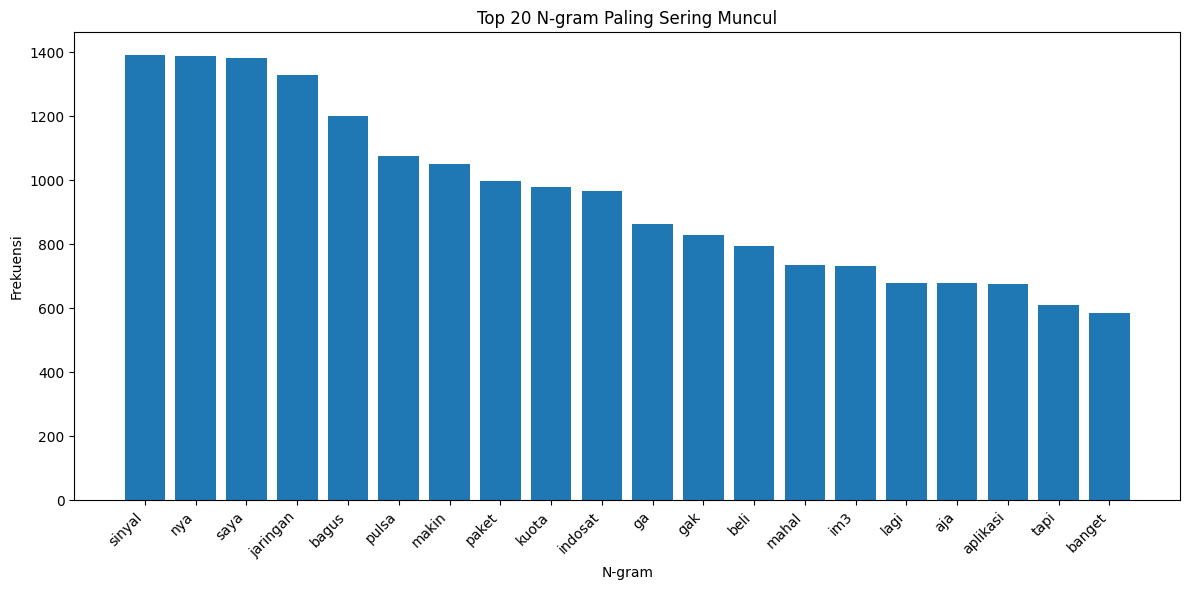

In [12]:
top_20_ngrams = ngram_df.head(20)

plt.figure(figsize=(12, 6))
plt.bar(top_20_ngrams["n_gram"], top_20_ngrams["frequency"])
plt.title("Top 20 N-gram Paling Sering Muncul")
plt.xlabel("N-gram")
plt.ylabel("Frekuensi")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

#12. Rata-rata Score berdasarkan Top 10 N-Gram

In [13]:
top_10_ngrams = ngram_df.head(10)["n_gram"].tolist()

avg_scores = []

for ngram in top_10_ngrams:
    reviews_with_ngram = df[df["clean_content"].str.contains(ngram, na=False)]

    if not reviews_with_ngram.empty:
        avg_score = reviews_with_ngram["score"].mean()
    else:
        avg_score = 0

    avg_scores.append(avg_score)

score_df = pd.DataFrame({
    "n_gram": top_10_ngrams,
    "average_score": avg_scores
})

print("Rata-rata score untuk Top 10 N-gram:")
display(score_df)

Rata-rata score untuk Top 10 N-gram:


,n_gram,average_score
0,sinyal,1.569343
1,nya,1.848796
2,saya,1.971526
3,jaringan,1.651341
4,bagus,3.909446
5,pulsa,1.554124
6,makin,1.463244
7,paket,1.720629
8,kuota,1.731308
9,indosat,1.602579


#13. Visualisasi Average Score

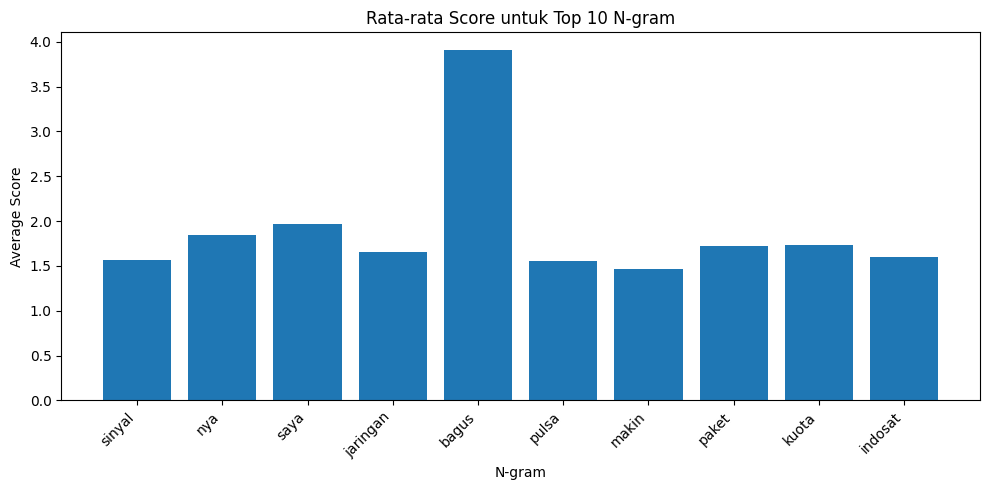

In [14]:
plt.figure(figsize=(10, 5))
plt.bar(score_df["n_gram"], score_df["average_score"])
plt.title("Rata-rata Score untuk Top 10 N-gram")
plt.xlabel("N-gram")
plt.ylabel("Average Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

#14. Trigram Comparison

In [15]:
vectorizer_tri = CountVectorizer(
    ngram_range=(3, 3),
    max_features=500,
    max_df=0.95,
    min_df=2
)

X_tri = vectorizer_tri.fit_transform(df["clean_content"])

tri_freq = X_tri.sum(axis=0)

tri_df = pd.DataFrame({
    "trigram": vectorizer_tri.get_feature_names_out(),
    "frequency": tri_freq.tolist()[0]
}).sort_values(by="frequency", ascending=False)

print("Top 10 Trigram Paling Sering Muncul:")
display(tri_df.head(10))

Top 10 Trigram Paling Sering Muncul:


,trigram,frequency
237,makin kesini makin,70
240,makin lama makin,51
38,beli paket data,46
234,makin hari makin,35
265,mau beli paket,27
402,saya kasih bintang,27
249,makin sini makin,27
397,saya beli paket,24
199,kuota masih banyak,23
53,buat main game,19


#15. Visualisasi Top 15 Trigram

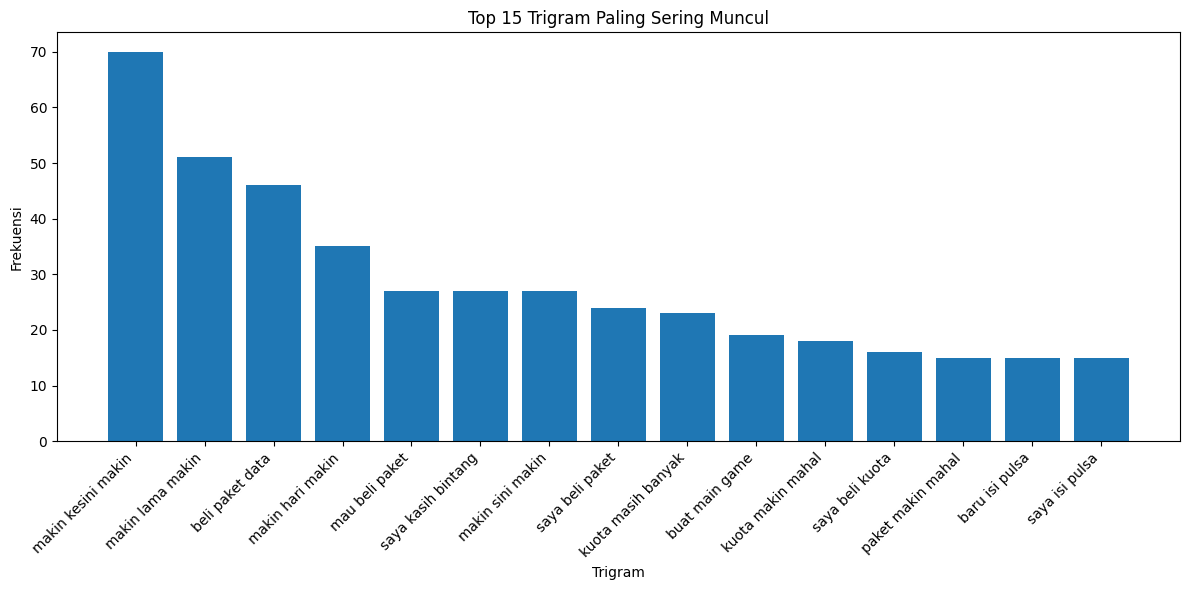

In [16]:
top_15_trigram = tri_df.head(15)

plt.figure(figsize=(12, 6))
plt.bar(top_15_trigram["trigram"], top_15_trigram["frequency"])
plt.title("Top 15 Trigram Paling Sering Muncul")
plt.xlabel("Trigram")
plt.ylabel("Frekuensi")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

#B. Penerapan Parsing (Constituency + Dependency)

#16. Install Library

In [17]:
!pip install stanza nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 773.7/773.7 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 418.7/418.7 kB 13.0 MB/s eta 0:00:00


#17. Download Model Bahasa Indonesia

In [18]:
import stanza
from nltk import Tree

stanza.download("id")

INFO:stanza:Downloaded file to /root/.cache/stanza/1.11.0/resources/resources.json
INFO:stanza:Downloading default packages for language: id (Indonesian) ...


INFO:stanza:Downloaded file to /root/.cache/stanza/1.11.0/resources/id/default.zip
INFO:stanza:Finished downloading models and saved to /root/.cache/stanza/1.11.0/resources


[['zip', 'default.zip']]

#18. Membuat Pipeline Parsing

In [19]:
nlp_const = stanza.Pipeline("id", processors="tokenize,pos,constituency")
nlp_dep = stanza.Pipeline("id", processors="tokenize,pos,lemma,depparse")

INFO:stanza:Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


INFO:stanza:Downloaded file to /root/.cache/stanza/1.11.0/resources/resources.json
INFO:stanza:Loading these models for language: id (Indonesian):
| Processor    | Package     |
------------------------------
| tokenize     | gsd         |
| mwt          | gsd         |
| pos          | gsd_charlm  |
| constituency | icon_charlm |

INFO:stanza:Using device: cpu
INFO:stanza:Loading: tokenize
INFO:stanza:Loading: mwt
INFO:stanza:Loading: pos
INFO:stanza:Loading: constituency
INFO:stanza:Done loading processors!
INFO:stanza:Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


INFO:stanza:Downloaded file to /root/.cache/stanza/1.11.0/resources/resources.json
INFO:stanza:Loading these models for language: id (Indonesian):
| Processor | Package      |
----------------------------
| tokenize  | gsd          |
| mwt       | gsd          |
| pos       | gsd_charlm   |
| lemma     | gsd_nocharlm |
| depparse  | gsd_charlm   |

INFO:stanza:Using device: cpu
INFO:stanza:Loading: tokenize
INFO:stanza:Loading: mwt
INFO:stanza:Loading: pos
INFO:stanza:Loading: lemma
INFO:stanza:Loading: depparse
INFO:stanza:Done loading processors!


#19. Ambil Data 1000 Review (Parsing Dataset)

In [20]:
df_1000 = df[["content", "clean_content", "score"]].dropna().head(1000).copy()
print("Jumlah review untuk parsing:", len(df_1000))
display(df_1000.head())

Jumlah review untuk parsing: 1000


,content,clean_content,score
0,Kenapa Indosat ada tuyulnya sekarang pulsa tib...,kenapa indosat tuyulnya sekarang pulsa tibatib...,1
1,aplikasi ini sangat bagus,aplikasi bagus,5
2,Tolong itu sistem login nomor utama dan nomor ...,tolong sistem login nomor utama nomor sekunder...,3
3,Sekarang pilihanya yg 30 hari naik terus harga...,sekarang pilihanya yg 30 hari naik terus harga...,4
4,murah,murah,5


#20. Fungsi Constituency Parsing

In [21]:
def get_constituency_tree(text):
    doc = nlp_const(text)
    results = []
    for sent in doc.sentences:
        results.append(str(sent.constituency))
    return results

#21. Output Constituency Parsing (100 Review)

In [23]:
print("===== CONSTITUENCY PARSING (100 REVIEW) =====")

for i in range(100):
    text = df_1000["content"].iloc[i]

    print("="*80)
    print(f"Review {i+1}: {text}\n")

    trees = get_constituency_tree(text)

    for t in trees:
        nltk_tree = Tree.fromstring(t)
        nltk_tree.pretty_print()

===== CONSTITUENCY PARSING (100 REVIEW) =====
Review 1: Kenapa Indosat ada tuyulnya sekarang pulsa tiba-tiba berkurang padahal saya tidak punya paket dan data seluler selalu mati,,, Apakah Indosat memelihara tuyul

                                                                                                            ROOT                                                                                                     
                                                                                                             |                                                                                                        
                                                                                                           SBARQ                                                                                                     
   __________________________________________________________________________________________________________|________________________________

#22. Fungsi Dependency Parsing

In [24]:
def get_dependency_relations(text):
    doc = nlp_dep(text)
    all_sentences = []

    for sent in doc.sentences:
        words = sent.words
        relations = []

        for w in words:
            relations.append({
                "word": w.text,
                "head": w.head,
                "deprel": w.deprel
            })

        all_sentences.append(relations)

    return all_sentences

#23. Output Dependency Parsing (100 Review)

In [25]:
print("===== DEPENDENCY PARSING (100 REVIEW) =====")

for i in range(100):
    text = df_1000["content"].iloc[i]

    print("="*80)
    print(f"Review {i+1}: {text}\n")

    doc = nlp_dep(text)

    for sent in doc.sentences:
        words = sent.words

        children = {i: [] for i in range(len(words)+1)}

        for idx, w in enumerate(words, start=1):
            children[w.head].append(idx)

        def recurse(node, prefix=""):
            if node == 0:
                print("ROOT")
                for child in children[0]:
                    recurse(child, "")
            else:
                w = words[node-1]
                label = f"{w.text} ({w.deprel})"
                print(prefix + "└── " + label)

                for child in children[node]:
                    recurse(child, prefix + "    ")

        recurse(0)

    print("\n")

===== DEPENDENCY PARSING (100 REVIEW) =====
Review 1: Kenapa Indosat ada tuyulnya sekarang pulsa tiba-tiba berkurang padahal saya tidak punya paket dan data seluler selalu mati,,, Apakah Indosat memelihara tuyul

ROOT
└── ada (root)
    └── Kenapa (advmod)
    └── Indosat (nsubj)
    └── tuyul (obj)
        └── nya (nmod:poss)
    └── berkurang (advcl)
        └── sekarang (obl)
            └── pulsa (compound)
        └── tiba-tiba (advmod)
        └── punya (advcl)
            └── padahal (mark)
            └── saya (nsubj)
            └── tidak (advmod)
            └── paket (obj)
                └── data (conj)
                    └── dan (cc)
                    └── seluler (amod)
                └── mati (amod)
                    └── selalu (advmod)
    └── memelihara (parataxis)
        └── , (punct)
        └── , (punct)
        └── , (punct)
        └── Apa (advmod)
            └── kah (advmod:emph)
        └── Indosat (nsubj)
        └── tuyul (obj)


Review 2: aplikasi ini 

#24. Menyimpan Hasil Constituency Parsing

In [26]:
output_const_file = "/content/drive/MyDrive/Colab Notebooks/TMFiturNGram/hasil_constituency_parsing.txt"

with open(output_const_file, "w", encoding="utf-8") as f:
    for i in range(len(df_1000)):
        text = df_1000["content"].iloc[i]
        trees = get_constituency_tree(text)

        f.write("="*80 + "\n")
        f.write(f"Review {i+1}: {text}\n\n")

        for t in trees:
            f.write(t + "\n")

        f.write("\n")

print("Hasil constituency parsing berhasil disimpan di:", output_const_file)

Hasil constituency parsing berhasil disimpan di: /content/drive/MyDrive/Colab Notebooks/TMFiturNGram/hasil_constituency_parsing.txt


#25. Menyimpan Hasil Dependency Parsing

In [27]:
output_dep_txt = "/content/drive/MyDrive/Colab Notebooks/TMFiturNGram/hasil_dependency_parsing.txt"

with open(output_dep_txt, "w", encoding="utf-8") as f:
    for i in range(len(df_1000)):
        text = df_1000["content"].iloc[i]
        doc = nlp_dep(text)

        f.write("="*80 + "\n")
        f.write(f"Review {i+1}: {text}\n\n")

        for sent_id, sent in enumerate(doc.sentences):
            f.write(f"Sentence {sent_id+1}:\n")

            for w in sent.words:
                # Format: kata --> head (relasi)
                f.write(f"{w.text} --> head:{w.head} ({w.deprel})\n")

            f.write("\n")

        f.write("\n")

print("Hasil dependency parsing berhasil disimpan di:", output_dep_txt)

Hasil dependency parsing berhasil disimpan di: /content/drive/MyDrive/Colab Notebooks/TMFiturNGram/hasil_dependency_parsing.txt
